In [9]:
import numpy as np
import os
import pandas as pd
import h5py
import matplotlib.pyplot as plt
try:
    from few.trajectory.geodesic import get_separatrix
except ImportError:
    from few.utils.geodesic import get_separatrix

from few.utils.mappings.kerrecceq import (AMAX_nex,apex_of_uwyz_nex, z_of_a_nex, a_of_z_nex,u_of_p_flux_nex, 
                _kerrecceq_flux_forward_map_nex, u_of_p_flux_nex,p_of_u_flux_nex,DELTAPMAX_REGIONC,DELTAPMIN_REGIONC)

from multispline.spline import BicubicSpline, TricubicSpline

In [2]:
apex_of_uwyz_nex(np.zeros(1),np.zeros(1),np.zeros(1),np.zeros(1)),apex_of_uwyz_nex(np.ones(1),np.ones(1),np.ones(1),np.ones(1))

((array([0.99]), array([1.47821168]), array([0.]), array([0.05])),
 (array([1.]), array([11.4000037]), array([0.4]), array([1.])))

In [3]:
def u_of_apex(a, p, e, x):
    """
    Compute the u parameter for a given set of parameters.
    """
    psep = get_separatrix(a, e, x)
    return np.log10(p - psep)

def w_of_apex(a, p, e, x):
    """
    Compute the w parameter for a given set of parameters.
    """
    return e

def z_of_apex(a, p, e, x):
    """
    Compute the a parameter for a given set of parameters.
    """
    return np.log10(1 - a)

def a_of_uwyz(u, w, y, z):
    """
    Compute the a parameter from u, w, y, z.
    """
    return 1 - 10**z

def p_of_uwyz(u, w, y, z):
    """
    Compute the p parameter from u, w, y, z.
    """
    a = a_of_uwyz(u, w, y, z)
    e = w
    x = 1.0
    psep = get_separatrix(a, e, x)
    return psep + 10**u

def e_of_uwyz(u, w, y, z):
    """
    Compute the e parameter from u, w, y, z.
    """
    return w

def apex_of_uwyz(u, w, y, z):
    """
    Compute the apex parameters (a, p, e, x) from u, w, y, z.
    """
    a = a_of_uwyz(u, w, y, z)
    e = w
    if isinstance(a, np.ndarray):
        x = np.ones_like(a)
    else:
        x = 1.0
    psep = get_separatrix(a, e, x)
    p = psep + 10**u
    return a, p, e, x


def z_of_a_nex(a):
    chimax = chi_of_a_nex(AMIN_nex)
    chimin = chi_of_a_nex(AMAX_nex)
    return (chi_of_a_nex(a) - chimin) / (chimax - chimin)

def u_of_p_nex(a):
    chimax = chi_of_a_nex(AMIN_nex)
    chimin = chi_of_a_nex(AMAX_nex)
    return (chi_of_a_nex(a) - chimin) / (chimax - chimin)

In [42]:
def u_of_p_nex2(p,pLSO):
    num = np.log10(p-pLSO) - np.log10(DELTAPMIN_REGIONC)
    den = np.log10(DELTAPMAX_REGIONC) - np.log10(DELTAPMIN_REGIONC)
    return num/den


def p_of_u_nex2(u,pLSO):
    return 10**(u*(np.log10(DELTAPMAX_REGIONC)-np.log10(DELTAPMIN_REGIONC)) + np.log10(DELTAPMIN_REGIONC))+pLSO

In [10]:
data_in = np.loadtxt('rectilinear_subset_v3.txt')

In [11]:
columns = ["a", "p", "e", "x", "pos", "Edot_tot", "Ldot_tot", "Qdot_tot", "Edot_hor", "Edot_inf", "Ldot_hor", "Ldot_inf", "Qdot_hor", "Qdot_inf", "timing (s)", "iu", "iw", "iz"]

In [12]:
df = pd.DataFrame(data_in, columns=columns)

In [7]:
data_grid = data_in.reshape(8, 9, 9, len(columns))
params_grid = data_grid[:, :, :, :4]

In [6]:
ug = np.linspace(0,1,9)
pg = p_of_u_flux_nex(ug,1)

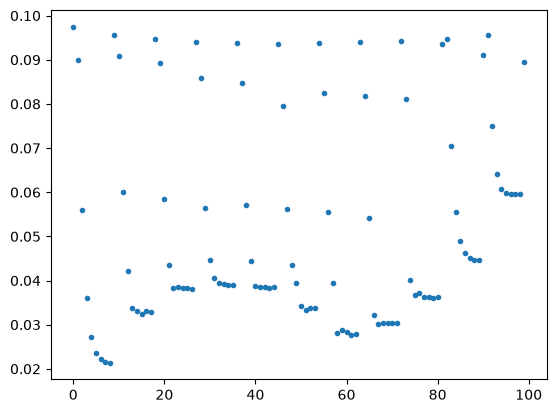

In [17]:
plt.plot(df["Edot_inf"][:100],".")

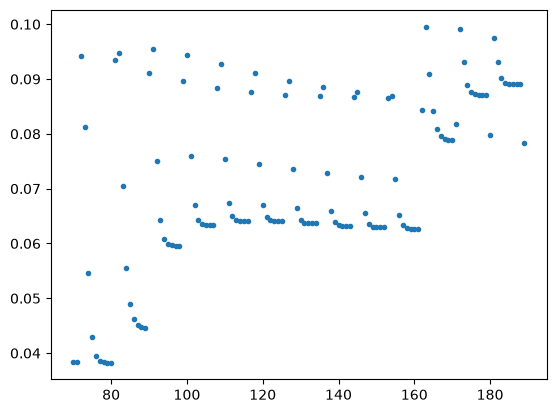

In [34]:
plt.plot(df["Edot_inf"][70:190],".")

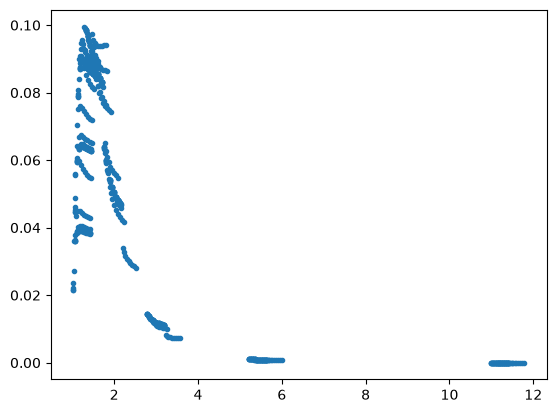

In [20]:
plt.plot(df["p"],df["Edot_inf"][:900],".")

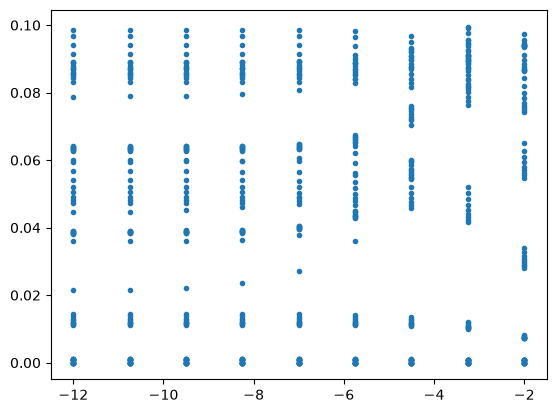

In [22]:
plt.plot(np.log10(1-df["a"]),df["Edot_inf"][:900],".")

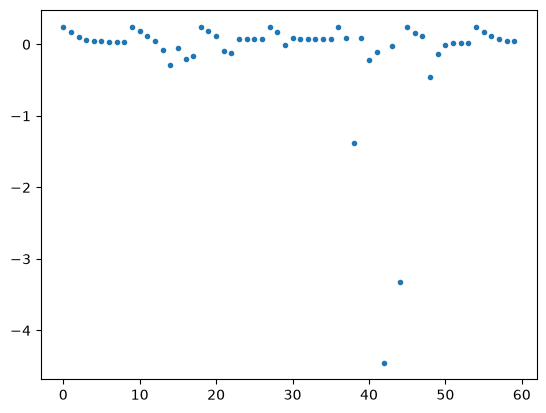

In [20]:
plt.plot(df["Ldot_tot"][:60],".")

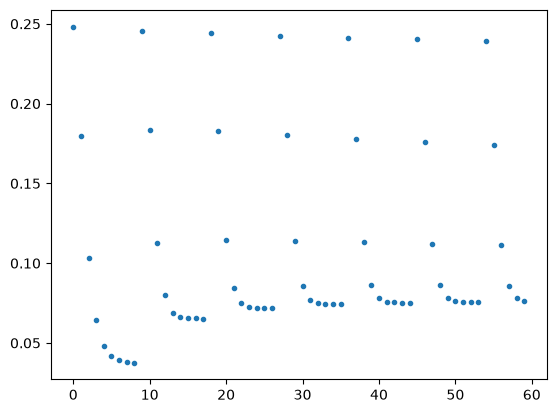

In [15]:
plt.plot(df["Ldot_tot"][:60],".")

In [22]:
df["p"][42]

np.float64(1.2237876568573285)

In [15]:
params_grid[:,:,8,:][:,:,2][0]

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 ])

In [16]:
params_grid[:,:,8,:][:,:,1][:,3]

array([ 1.17371824,  1.20623864,  1.28335665,  1.46623227,  1.89989871,
        2.92828391,  5.36696954, 11.1500045 ])

In [17]:
pmin, pmax =  1.17371824,11.1500045

In [18]:
psep = get_separatrix(AMAX_nex,0.15,1)
psep

1.1500045033529742

In [14]:
pmin-psep 

0.023713736647025696

In [15]:
pmax-psep 

9.999999996647025

In [16]:
pmin-psep

0.023713736647025696

In [17]:
#Copied / modified from the data_set_preprocessing

In [18]:
with pd.option_context('display.max_rows', None,
    'display.max_columns', 12,
    'display.width', 13000,
    'display.precision', 10):
        print(df)

                a              p     e    x     pos      Edot_tot  ...          Qdot_hor          Qdot_inf        timing (s)   iu   iw   iz
0    0.9900000000   1.4782116751  0.00  1.0   756.0  0.0890756560  ...  0.0000000000e+00  0.0000000000e+00      0.0000000000  1.0  0.0  0.0
1    0.9994376587   1.1703051822  0.00  1.0   730.0  0.0792126358  ...  0.0000000000e+00  0.0000000000e+00      0.0000000000  1.0  0.0  1.0
2    0.9999683772   1.0761466696  0.00  1.0   776.0  0.0487213052  ...  0.0000000000e+00  0.0000000000e+00      0.0000000000  1.0  0.0  2.0
3    0.9999982217   1.0432708450  0.00  1.0   732.0  0.0311785366  ...  0.0000000000e+00  0.0000000000e+00      0.0000000000  1.0  0.0  3.0
4    0.9999999000   1.0311293963  0.00  1.0   742.0  0.0234783125  ...  0.0000000000e+00  0.0000000000e+00      0.0000000000  1.0  0.0  4.0
5    0.9999999944   1.0265435573  0.00  1.0   752.0  0.0203751351  ...  0.0000000000e+00  0.0000000000e+00      0.0000000000  1.0  0.0  5.0
6    0.9999999997   

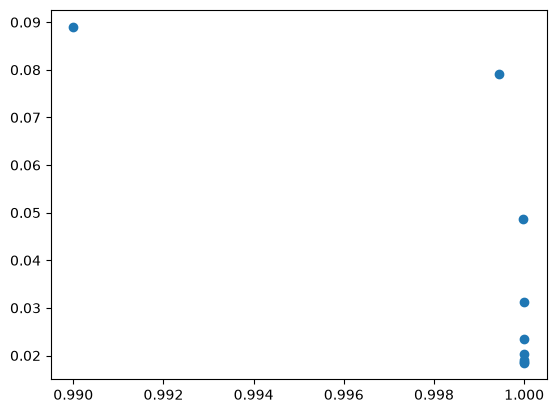

In [19]:
plt.scatter(df["a"][:9],df["Edot_tot"][:9])

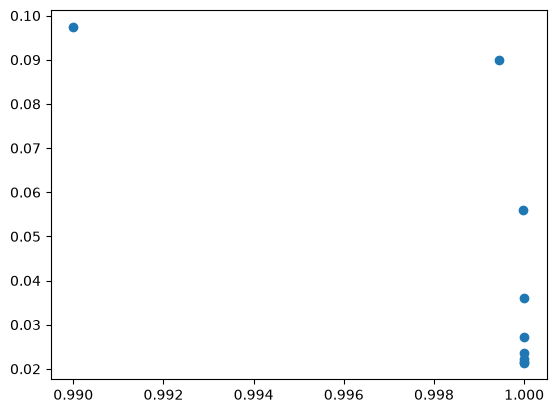

In [20]:
plt.scatter(df["a"][:9],df["Edot_inf"][:9])

In [8]:


#  set to the location of the raw data files
data_loc = "rectilinear_subset_v3.txt"

with h5py.File('KerrEccEqFluxData_nex.h5', 'w') as outfile:
    # region A
  #  dataA = pd.read_feather(os.path.join(data_loc))
   # df_infoA = pd.read_feather(os.path.join(data_loc, 'flux_grid_params_inner.feather'))
    dataA = df
    df_infoA = params_grid

    NU = 8
    NW = 9
    NZ = 9

    regionA = outfile.create_group('regionA')
    regionA.create_dataset('Edot', data=dataA["Edot_tot"].to_numpy().reshape(NU, NW, NZ)[:,:,:])
    regionA.create_dataset('Ldot', data=dataA["Ldot_tot"].to_numpy().reshape(NU, NW, NZ)[:,:,:])

    regionA.attrs['NU'] = NU
    regionA.attrs['NW'] = NW
    regionA.attrs['NZ'] = NZ


In [22]:
#test class

In [2]:
fp = "KerrEccEqFluxData_nex.h5"  #Will change filename


file_path = fp

with h5py.File(file_path, "r") as fluxData:
    regionA = fluxData["regionA"]
    u = np.linspace(0, 1, regionA.attrs["NU"])
    w = np.linspace(0, 1, regionA.attrs["NW"])
    z = np.linspace(0, 1, regionA.attrs["NZ"])

    ugrid, wgrid, zgrid = np.asarray(
        np.meshgrid(u, w, z, indexing="ij")
    ).reshape(3, -1)
    agrid, pgrid, egrid, xgrid = apex_of_uwyz_nex(
        ugrid, wgrid, np.ones_like(zgrid), zgrid
    )

    # normalise by PN contribution
    Edot = regionA["Edot"][()]
    Ldot = regionA["Ldot"][()]
    


    Edot_interp_A = TricubicSpline(u, w, z, Edot)
    Ldot_interp_A = TricubicSpline(u, w, z, Ldot)

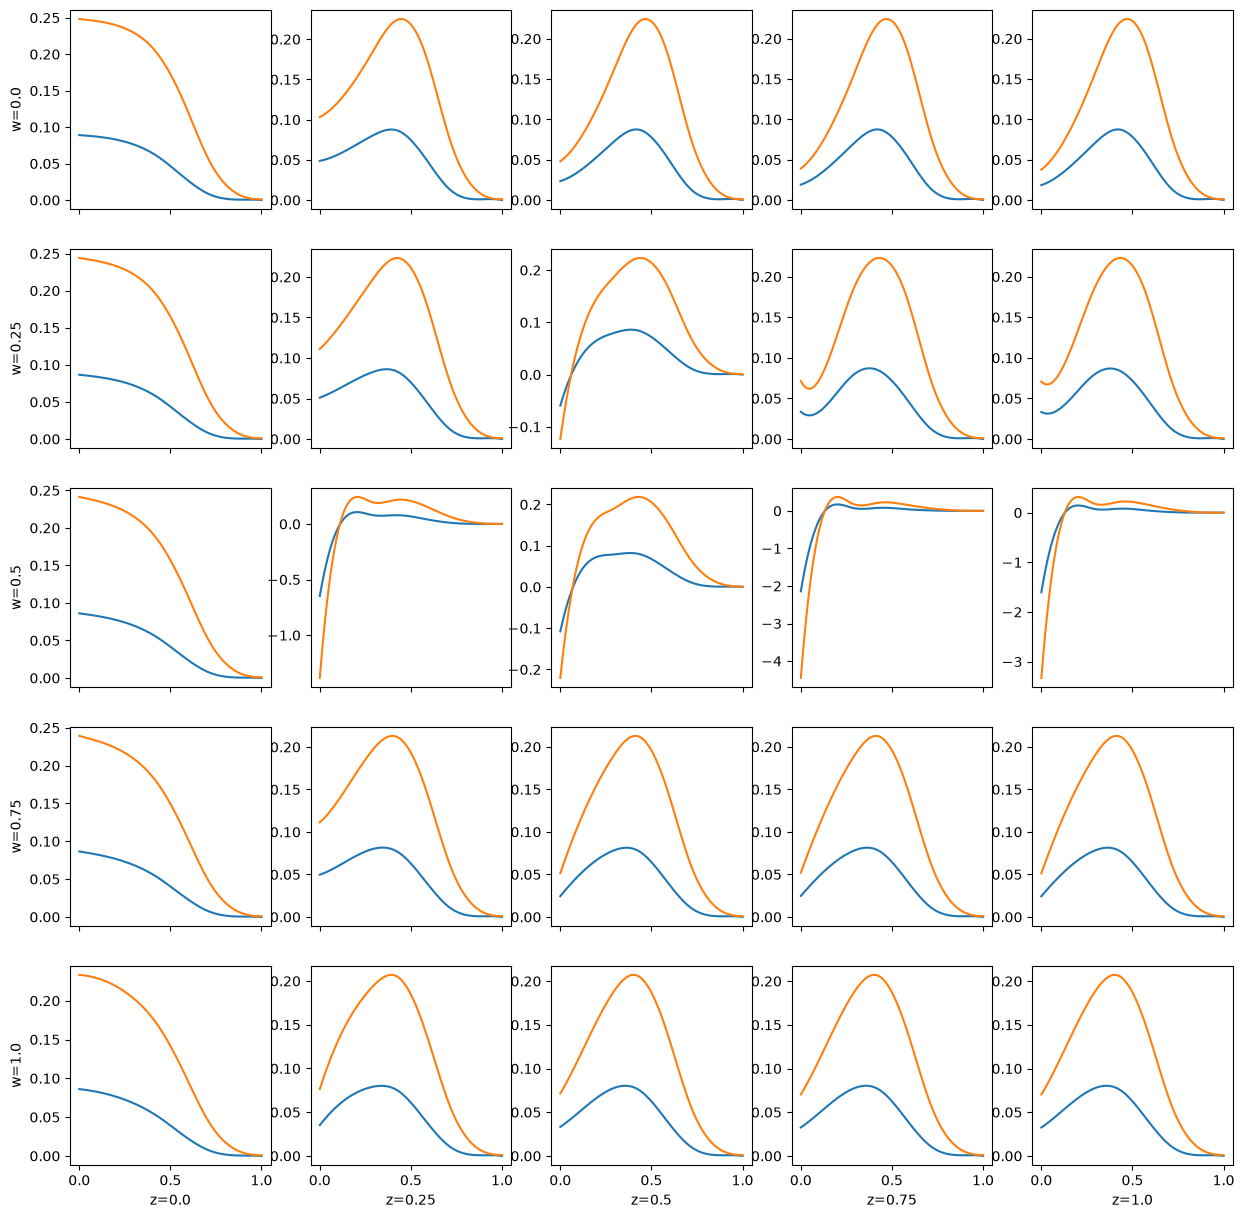

In [4]:
new_ugrid = np.linspace(0,1,100)
nz=5
nw=5

w_vals = np.linspace(0,1,nw)#[0,0.5,0.7,0.9]
z_vals = np.linspace(0,1,nz) #[0,0.2,0.5,0.7,0.8,0.87,0.875,0.9,0.99]


fig,axs = plt.subplots(len(w_vals),len(z_vals),figsize = (3*len(z_vals),3*len(w_vals)),sharex=True,sharey=False)


for i in range(len(w_vals)):
    for j in range(len(z_vals)):

        z = z_vals[j]
        w = w_vals[i]

        axs[i,j].plot(new_ugrid,Edot_interp_A(new_ugrid,w,z),label = r"$\dot{E}$")
        axs[i,j].plot(new_ugrid,Ldot_interp_A(new_ugrid,w,z),label = r"$\dot{L}$")

        if i == len(w_vals) -1 :
            axs[i,j].set_xlabel(f"z={z}")
        if j == 0 :
            axs[i,j].set_ylabel(f"w={w}")

#axs[0].set_xlabel("u")
#axs[0].set_ylabel(r"$\dot{E}$")

#axs[1].set_xlabel("u")
#axs[1].set_ylabel(r"$\dot{L}$")

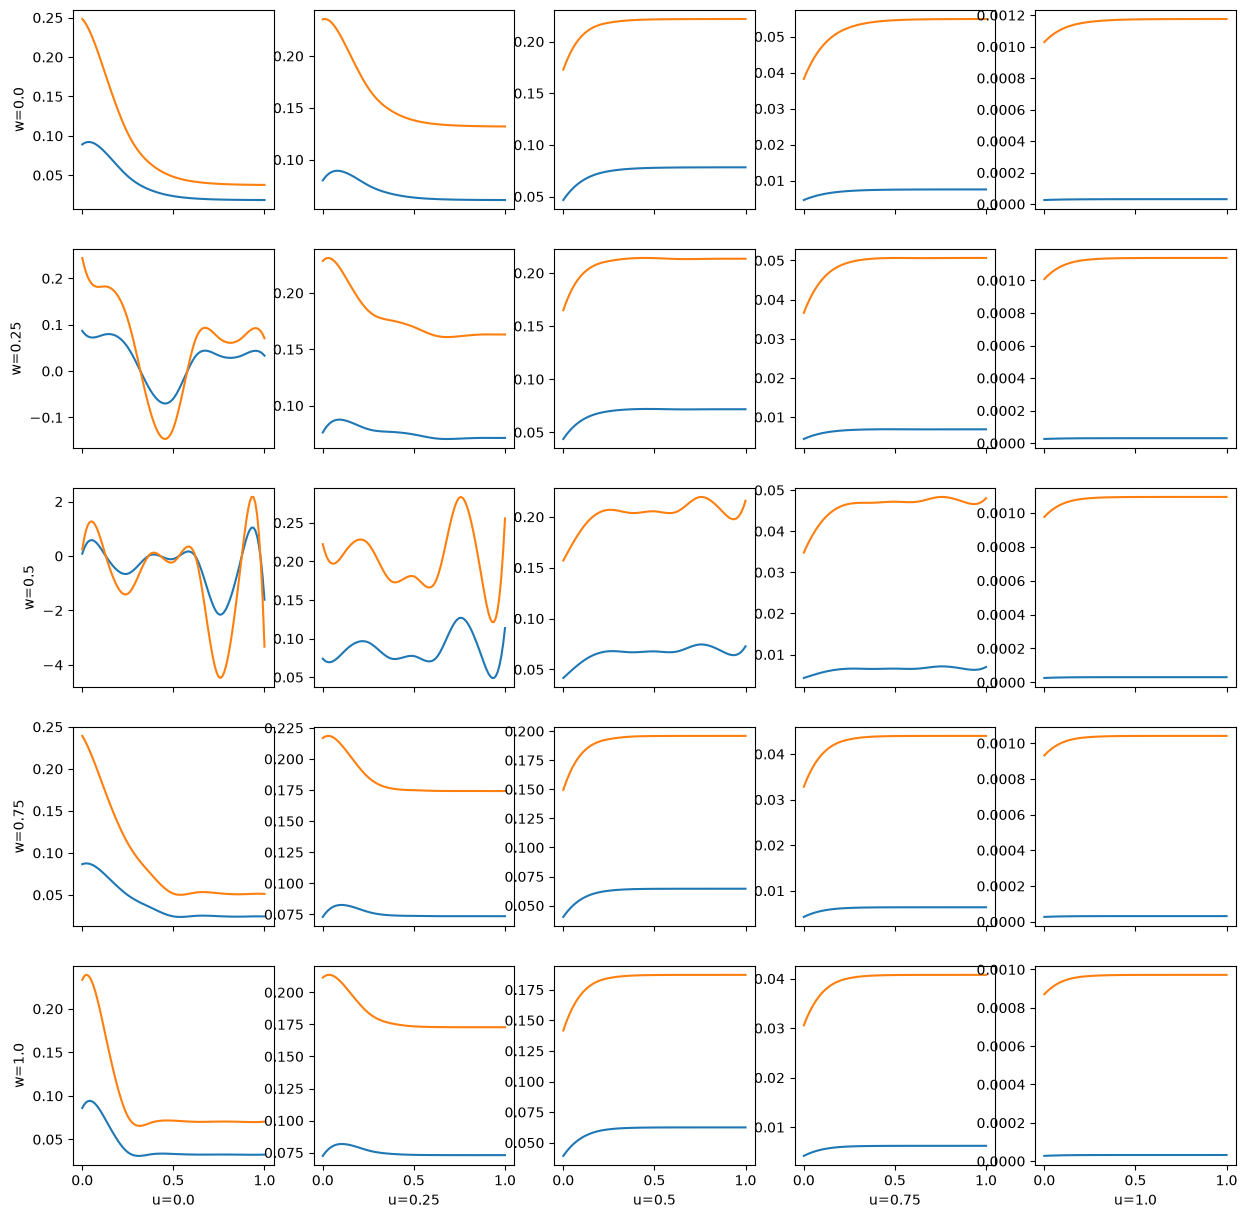

In [4]:
new_zgrid = np.linspace(0,1,100)
nu= 5
nw=5

w_vals = np.linspace(0,1,nw)#[0,0.5,0.7,0.9]
u_vals = np.linspace(0,1,nu) #[0,0.2,0.5,0.7,0.8,0.87,0.875,0.9,0.99]


fig,axs = plt.subplots(len(w_vals),len(u_vals),figsize = (3*len(z_vals),3*len(w_vals)),sharex=True,sharey=False)


for i in range(len(w_vals)):
    for j in range(len(u_vals)):

        u = u_vals[j]
        w = w_vals[i]

        axs[i,j].plot(new_ugrid,Edot_interp_A(u,w,new_zgrid),label = r"$\dot{E}$")
        axs[i,j].plot(new_ugrid,Ldot_interp_A(u,w,new_zgrid),label = r"$\dot{L}$")

        if i == len(w_vals) -1 :
            axs[i,j].set_xlabel(f"u={u}")
        if j == 0 :
            axs[i,j].set_ylabel(f"w={w}")

#axs[0].set_xlabel("u")
#axs[0].set_ylabel(r"$\dot{E}$")

#axs[1].set_xlabel("u")
#axs[1].set_ylabel(r"$\dot{L}$")

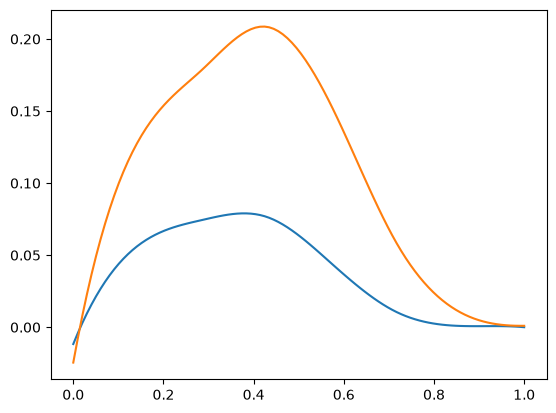

In [5]:
w=0.9
z=0.9

plt.plot(new_ugrid,Edot_interp_A(new_ugrid,w,z),label = r"$\dot{E}$")
plt.plot(new_ugrid,Ldot_interp_A(new_ugrid,w,z),label = r"$\dot{L}$")

Text(0, 0.5, '$\\dot{L}$')

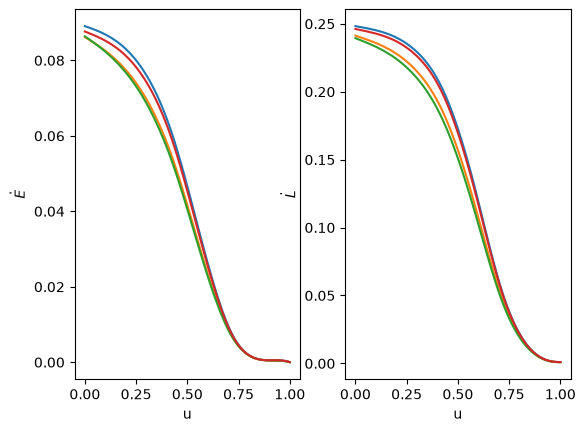

In [6]:
new_ugrid = np.linspace(0,1,100)

fig,axs = plt.subplots(1,2)

w_vals = [0,0.5,0.7,0.1]

for i in range(len(w_vals)):
    for j in range(len(w_vals)):
        w,z = w_vals[i], w_vals[j]

    axs[0].plot(new_ugrid,Edot_interp_A(new_ugrid,w,0))
    axs[1].plot(new_ugrid,Ldot_interp_A(new_ugrid,w,0))

axs[0].set_xlabel("u")
axs[0].set_ylabel(r"$\dot{E}$")

axs[1].set_xlabel("u")
axs[1].set_ylabel(r"$\dot{L}$")

In [7]:

plt.plot(df["e"])
plt.grid()

NameError: name 'df' is not defined

In [29]:
len(pgrid),len(df["p"])

(648, 648)

In [30]:
for a in df["p"]:
    print(a)

1.4782116751162881
1.170305182233175
1.0761466695695716
1.0432708450441162
1.0311293962945765
1.0265435573430977
1.0247962444980552
1.024128223188449
1.0238724878578676
1.5058746787877642
1.1968097589805746
1.108029924976309
1.0825014508785353
1.0758481982871733
1.0742230257886685
1.073834688604852
1.0737424293378135
1.0737205407999442
1.5393453000363944
1.2332564727828095
1.1516880024396423
1.1305282382970696
1.125341488287341
1.1241004257802862
1.1238054744485346
1.1237354936337107
1.123718896785206
1.5772983821063158
1.2750244526615964
1.1986347510077622
1.1796943978542305
1.1751363599628784
1.1740513465154911
1.1737938111466142
1.173732726341592
1.1737182404095907
1.6187039675174233
1.3198099438213424
1.2469145587839414
1.2292466153494126
1.2250276739431687
1.2240254285296919
1.2237876568573285
1.223731266676664
1.2237178940800983
1.6627823949698188
1.3664337823830426
1.2958691826424928
1.2789805809700538
1.274963488179258
1.2740101447288064
1.27378402892736
1.2737304060249957
1.27

In [31]:
for a in pgrid:
    print(a)

1.4782116751162881
1.1703050322457988
1.0761465687336025
1.0432707900591245
1.0311293687827112
1.0265435442517201
1.0247962383993985
1.0241282209874063
1.0238724878578676
1.5058746787877642
1.1968096117616496
1.1080298379177886
1.0825014155043327
1.075848186579462
1.0742230222708722
1.0738346876083804
1.0737424291586823
1.0737205407999442
1.5393453000363944
1.233256332075832
1.1516879275469285
1.1305282102940954
1.1253414793065804
1.1241004231073763
1.123805473707483
1.1237354934428452
1.123718896785206
1.5772983821063158
1.275024317822525
1.1986346831010453
1.179694373145551
1.1751363521032738
1.174051344181255
1.1737938105051708
1.1737327261953152
1.1737182404095907
1.6187039675174233
1.319809813430152
1.2469144950753819
1.2292465924423839
1.2250276666814377
1.2240254263718233
1.2237876562263288
1.2237312663329072
1.2237178940800983
1.6627823949698188
1.36643365514929
1.2958691215634044
1.2789805591417864
1.2749634812696093
1.2740101426768777
1.273784028347127
1.2737304058018575
1.27

In [9]:
a,p,e,x = 0.98,5,0.4,1
pLSO = get_separatrix(a,e,x)

a_in =a

_kerrecceq_flux_forward_map_nex(a_in, p, e, 1.0,pLSO)

(0.8036007746021796, 1.0, 1.0, -0.03010297064512788, 'RegionC')

In [10]:
print(max(df["p"]),max(pgrid))
print(min(df["p"]),min(pgrid))

11.782185235603935 11.782185235603933
1.0238724878578676 1.0238724878578676


In [11]:
print(max(df["p"])-max(pgrid))
print(min(df["p"])-min(pgrid))

1.7763568394002505e-15
0.0


In [12]:
from math import log

log(np.exp(1))

1.0

In [8]:
plt.plot(egrid-df["e"])

NameError: name 'df' is not defined

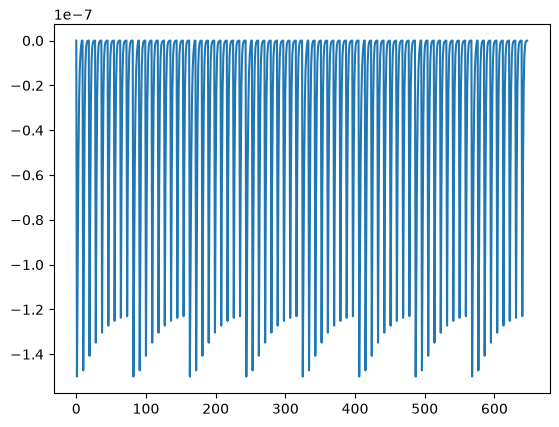

In [19]:
plt.plot((pgrid-df["p"]))


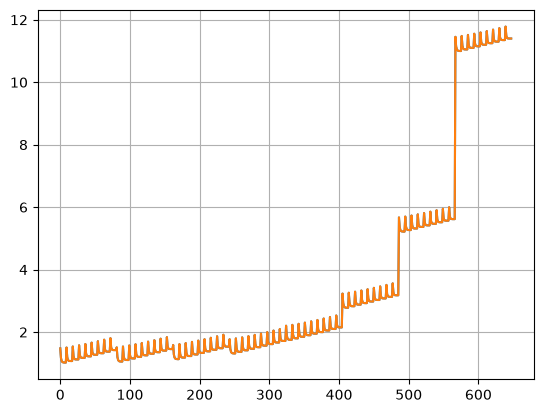

In [20]:
plt.plot(pgrid)
plt.plot((df["p"]))
plt.grid()